<a href="https://colab.research.google.com/github/Siraj0335/Final-Year-Project-Student-Psychological-Wellness-Siraj-Uddin-Mohammad-/blob/main/Revised_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification of Student Psychological Wellness — Corrected Pipeline
**Student:** Siraj Uddin Mohammad (24089738)  
**Module:** 7PAM2002 Data Science Project

In [2]:
import pandas as pd, numpy as np, warnings
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
from sklearn.model_selection import (train_test_split, cross_validate, cross_val_score,
                                     StratifiedKFold, GridSearchCV)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils import resample
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score)
from scipy import stats

df = pd.read_csv('Student Smoking, Alcohol, and Mental Health Dataset_version-2.csv')
print(df.shape)
df.head()

(1164, 14)


,Timestamp,Age,Year of study,Field of study,Frequency of smoking,Age of starting smoking,Reasons for smoking,Frequency of alcohol consumption,Typical alcohol intake in a week,Reasons for consuming alcohol,To cope with stress,Help-seeking behavior for mental health,Interest in reducing or quitting smoking/alcohol consumption,Psychological Wellness
0,10/24/2024 8:12:57,24-26,Graduate student,Science and Technology,Don’t smoke,Don’t smoke,Don’t smoke,Don’t consume alcohol,Don’t drink alcohol,Don’t drink alcohol,Other,No,No,Good
1,10/24/2024 12:39:11,24-26,Graduate student,Science and Technology,Daily,21-23,Habit or addiction,Don’t consume alcohol,Don’t drink alcohol,Don’t drink alcohol,Smoking,Yes,Yes,Good
2,10/24/2024 13:03:48,27 or older,4th year,Business and Economics,Daily,18-20,Curiosity,Only on social occasions,3-5 drinks,Social purposes,Drinking alcohol,Yes,No,Good
3,10/24/2024 13:04:10,21-23,Graduate student,Arts and Humanities,Daily,21-23,To reduce stress,Daily,1-2 drinks,To relax,Exercise,Yes,Yes,Excellent
4,10/24/2024 13:04:39,18-20,3rd year,Social Sciences,Weekly,24 or older,Curiosity,Only on social occasions,1-2 drinks,To relax,Drinking alcohol,Yes,Yes,Excellent


## 1. Target definition

Wellness_Grouped
Medium    558
Poor      493
High      113
Name: count, dtype: int64


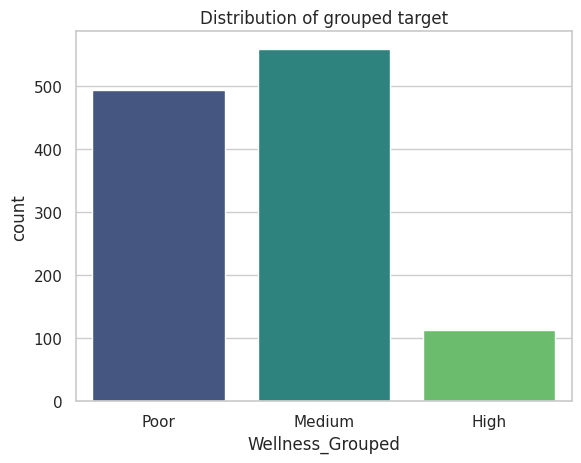

In [3]:
wellness_map = {'Poor':'Poor','Below average':'Medium','Average':'Medium','Good':'High','Excellent':'High'}
df['Wellness_Grouped'] = df['Psychological Wellness'].map(wellness_map)
print(df['Wellness_Grouped'].value_counts())
sns.countplot(x='Wellness_Grouped', data=df, order=['Poor','Medium','High'], palette='viridis')
plt.title('Distribution of grouped target'); plt.show()

## 2. The data-leakage bug, demonstrated
Below we reproduce the **original (buggy)** feature construction, which kept `Psychological Wellness`.
The accuracy is a perfect 1.00 — not a real result, just the model reading a copy of the label.
This cell is kept only to **document** the problem; it is not used for the final results.

In [4]:
# --- ORIGINAL BUGGY VERSION (for demonstration only) ---
X_leak = pd.get_dummies(df.drop(columns=['Timestamp','Wellness_Grouped']), drop_first=True)
le = LabelEncoder(); y = le.fit_transform(df['Wellness_Grouped'])
Xtr,Xte,ytr,yte = train_test_split(X_leak,y,test_size=0.2,random_state=42,stratify=y)
sc=StandardScaler(); lr=LogisticRegression(max_iter=1000).fit(sc.fit_transform(Xtr),ytr)
print('Leaky LR accuracy:', round(accuracy_score(yte,lr.predict(sc.transform(Xte))),4))
print('Leaking columns still present:', [c for c in X_leak.columns if 'Psychological Wellness' in c])

Leaky LR accuracy: 1.0
Leaking columns still present: ['Psychological Wellness_Below average', 'Psychological Wellness_Excellent', 'Psychological Wellness_Good', 'Psychological Wellness_Poor']


## 3. Corrected feature matrix (leakage removed)
We now drop **both** the original `Psychological Wellness` and the derived `Wellness_Grouped`,
plus the non-predictive `Timestamp`, before one-hot encoding.

In [5]:
X = pd.get_dummies(df.drop(columns=['Timestamp','Psychological Wellness','Wellness_Grouped']), drop_first=True)
le = LabelEncoder(); y = le.fit_transform(df['Wellness_Grouped']); classes = list(le.classes_)
assert not any('Psychological Wellness' in c for c in X.columns), 'Leakage still present!'
print('Encoded classes:', dict(enumerate(classes)))
print('Features after leakage removal:', X.shape[1])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on TRAIN only (no leakage from test)
X_test_s  = scaler.transform(X_test)

Encoded classes: {0: 'High', 1: 'Medium', 2: 'Poor'}
Features after leakage removal: 42


## 4. How the models work (technical explanation)

**Logistic Regression (multinomial).** For a 3-class problem we use *multinomial* (softmax) logistic
regression, **not** plain linear regression. Linear regression predicts an unbounded continuous number and
is only appropriate for regression; binary logistic regression handles two classes. The multinomial version
learns one weight vector per class and converts the scores into class probabilities with the softmax
function, predicting the class with the highest probability. (The viva noted "linear regression for a
3-class problem" — this corrected version makes the multinomial classification explicit.)

**Support Vector Machine (SVM).** Finds the hyperplane that separates classes with the largest possible
margin (gap). `C` controls the trade-off between a wide margin and misclassifying training points; a linear
kernel assumes the classes are roughly linearly separable.

**Decision Tree.** Splits the data with yes/no questions on features, choosing at each node the split that
most reduces impurity (Gini). It keeps splitting until leaves are pure or a stopping rule is hit. Single
trees overfit easily.

**Random Forest.** An *ensemble* of many decision trees. Each tree is trained on a bootstrap sample of the
rows and a random subset of features at each split; the final prediction is the majority vote of all trees.
`n_estimators` is the **number of trees** in the forest (e.g. 100). More trees reduce variance and make the
prediction more stable, at the cost of compute. Randomness across trees is what makes the forest generalise
better than a single tree.

**MLP (neural network).** A small feed-forward network (hidden layers of 64 and 32 neurons with ReLU) that
learns non-linear combinations of features through backpropagation.

## 5. Evaluation metrics (technical explanation)

**Confusion matrix.** A table whose rows are the *true* classes and columns are the *predicted* classes.
The diagonal counts correct predictions; off-diagonal cells show exactly which classes get confused for which.
For 3 classes it is a 3x3 grid. From it we derive precision and recall per class.

**Precision** = of all items predicted as class k, how many were actually k: TP / (TP+FP).
**Recall** = of all true class-k items, how many we found: TP / (TP+FN).
**F1** = harmonic mean of precision and recall. **Macro-F1** averages F1 equally across the three classes,
so the small **High** class counts as much as the large ones — the right headline metric for imbalanced data.
**ROC-AUC (one-vs-rest, macro)** measures ranking quality across thresholds; 0.5 = random, 1.0 = perfect.

In [6]:
models = {
 'Logistic Regression': LogisticRegression(max_iter=1000),      # multinomial softmax
 'SVM': SVC(probability=True, kernel='linear', random_state=42),
 'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),  # 100 trees
 'MLP': MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42),
}
results={}
for name,m in models.items():
    m.fit(X_train_s, y_train)
    yp = m.predict(X_test_s); proba = m.predict_proba(X_test_s)
    results[name]={'y_pred':yp,'proba':proba,
        'acc':accuracy_score(y_test,yp),
        'f1_macro':f1_score(y_test,yp,average='macro'),
        'f1_weighted':f1_score(y_test,yp,average='weighted'),
        'auc':roc_auc_score(y_test,proba,multi_class='ovr',average='macro'),
        'cm':confusion_matrix(y_test,yp)}
summary=pd.DataFrame({n:{'Accuracy':r['acc'],'F1-macro':r['f1_macro'],
        'F1-weighted':r['f1_weighted'],'ROC-AUC':r['auc']} for n,r in results.items()}).T
print(summary.round(3))

                     Accuracy  F1-macro  F1-weighted  ROC-AUC
Logistic Regression     0.652     0.669        0.650    0.773
SVM                     0.661     0.667        0.651    0.785
Random Forest           0.579     0.636        0.577    0.768
MLP                     0.588     0.625        0.586    0.740


In [7]:
# Class-wise precision / recall / F1 for the best baseline model (SVM)
print(classification_report(y_test, results['SVM']['y_pred'], target_names=classes))

              precision    recall  f1-score   support

        High       0.68      0.77      0.72        22
      Medium       0.63      0.80      0.71       112
        Poor       0.72      0.47      0.57        99

    accuracy                           0.66       233
   macro avg       0.68      0.68      0.67       233
weighted avg       0.67      0.66      0.65       233



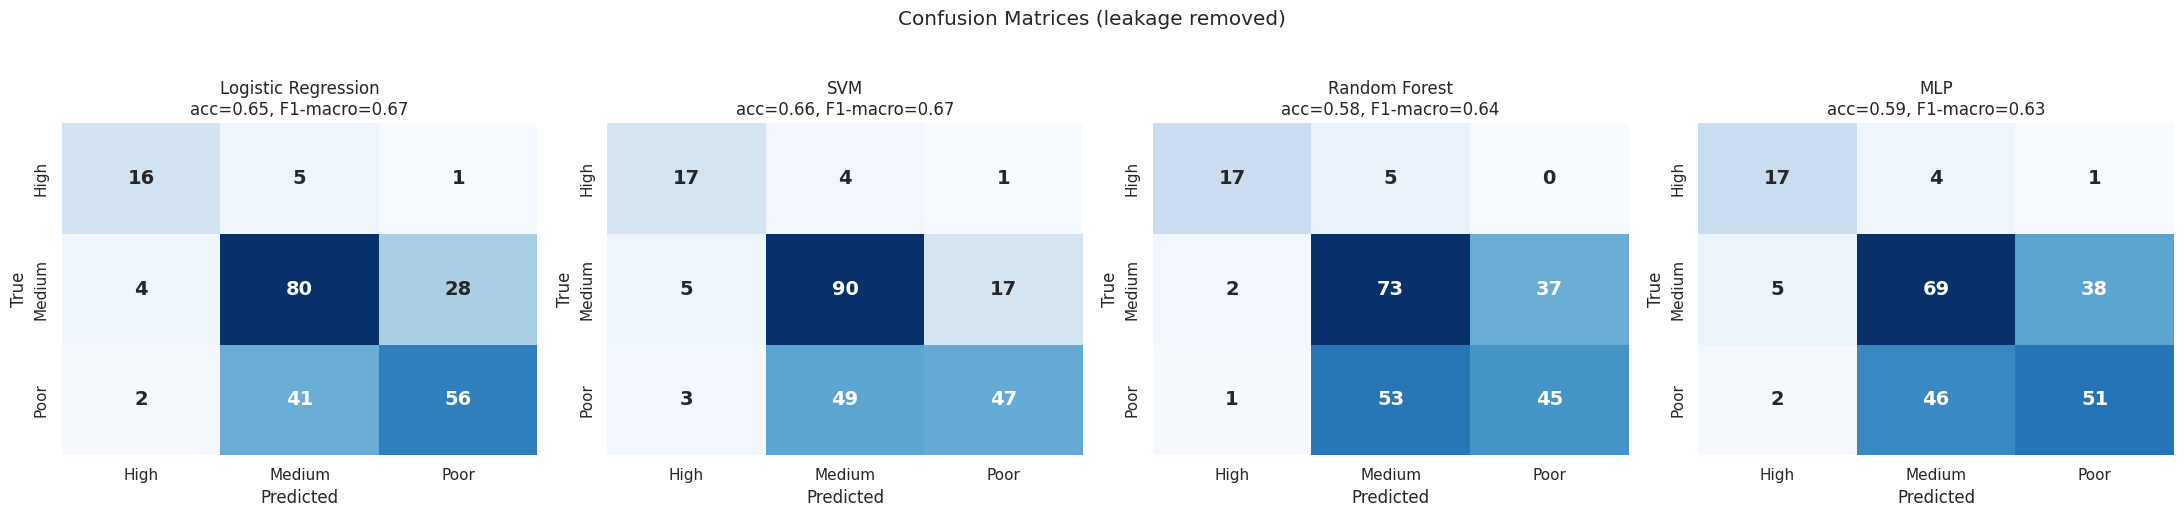

In [8]:
# Confusion matrices for all models
fig,axes=plt.subplots(1,4,figsize=(22,5))
for ax,(name,r) in zip(axes,results.items()):
    sns.heatmap(r['cm'],annot=True,fmt='d',cmap='Blues',cbar=False,
                xticklabels=classes,yticklabels=classes,ax=ax,annot_kws={'size':14,'weight':'bold'})
    ax.set_title(f"{name}\nacc={r['acc']:.2f}, F1-macro={r['f1_macro']:.2f}")
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle('Confusion Matrices (leakage removed)',y=1.03); plt.tight_layout(); plt.show()

### Figure 1 — Visualising the data-leakage impact
Bar chart of test accuracy *with* the leak (an invalid 100%) versus *after* removing the leaking columns, for the two linear models. This reproduces Figure 1 in the report.

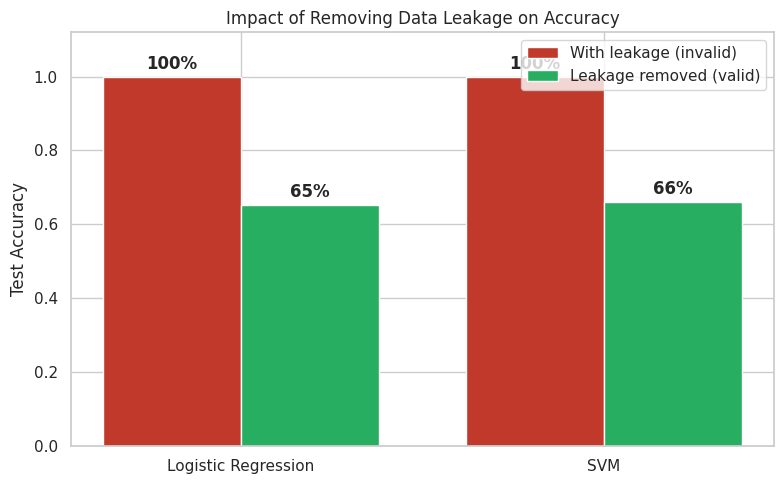

Leaky vs corrected accuracy: {'Logistic Regression': (1.0, 0.652), 'SVM': (1.0, 0.661)}


In [9]:
# Figure 1 — Impact of removing data leakage on accuracy (LR & SVM)
import os
os.makedirs('figures', exist_ok=True)
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(X_leak, y, test_size=0.2, random_state=42, stratify=y)
_scl = StandardScaler(); Xl_tr = _scl.fit_transform(Xl_tr); Xl_te = _scl.transform(Xl_te)
leak_models = {'Logistic Regression': LogisticRegression(max_iter=1000),
               'SVM': SVC(kernel='linear', random_state=42)}
leak_acc = {n: accuracy_score(yl_te, m.fit(Xl_tr, yl_tr).predict(Xl_te)) for n, m in leak_models.items()}
corr_acc = {n: results[n]['acc'] for n in leak_models}

labels = list(leak_models); x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, [leak_acc[n] for n in labels], w, color='#c0392b', label='With leakage (invalid)')
b2 = ax.bar(x + w/2, [corr_acc[n] for n in labels], w, color='#27ae60', label='Leakage removed (valid)')
for bars in (b1, b2):
    for r in bars:
        ax.text(r.get_x()+r.get_width()/2, r.get_height()+0.01, f'{r.get_height()*100:.0f}%',
                ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Test Accuracy'); ax.set_ylim(0, 1.12)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title('Impact of Removing Data Leakage on Accuracy'); ax.legend()
plt.tight_layout(); plt.savefig('figures/fig1_leakage_before_after.png', dpi=130, bbox_inches='tight'); plt.show()
print('Leaky vs corrected accuracy:', {n: (round(leak_acc[n], 3), round(corr_acc[n], 3)) for n in labels})

## 6. Class balancing — deeper analysis
The target is imbalanced (Medium 558, Poor 493, High 113). We compare four strategies on each model and
report **macro-F1** (sensitive to the minority class):
- **Original** — no balancing.
- **Oversample** — duplicate minority-class rows up to the majority size.
- **Undersample** — drop majority-class rows down to the minority size.
- **Class-Weighted** — keep the data but penalise minority errors more (`class_weight='balanced'`).

Resampling is applied to the **training set only**, never the test set.

In [10]:
def upsample(Xa,ya):
    d=pd.DataFrame(Xa); d['y']=ya; mx=d['y'].value_counts().max(); parts=[]
    for _,g in d.groupby('y'):
        parts.append(resample(g,replace=True,n_samples=mx,random_state=42) if len(g)<mx else g)
    r=pd.concat(parts); return r.drop(columns='y').values, r['y'].values
def downsample(Xa,ya):
    d=pd.DataFrame(Xa); d['y']=ya; mn=d['y'].value_counts().min(); parts=[]
    for _,g in d.groupby('y'):
        parts.append(resample(g,replace=False,n_samples=mn,random_state=42) if len(g)>mn else g)
    r=pd.concat(parts); return r.drop(columns='y').values, r['y'].values

def make(name,cw=None):
    if name=='Logistic Regression': return LogisticRegression(max_iter=1000,class_weight=cw)
    if name=='SVM': return SVC(kernel='linear',probability=True,class_weight=cw,random_state=42)
    if name=='Random Forest': return RandomForestClassifier(n_estimators=100,class_weight=cw,random_state=42)
    return MLPClassifier(hidden_layer_sizes=(64,32),max_iter=500,random_state=42)

rows=[]
for name in models:
    for strat in ['Original','Oversample','Undersample','Class-Weighted']:
        if strat=='Class-Weighted' and name=='MLP': continue  # MLP has no class_weight
        if strat=='Original': Xt,yt,clf=X_train_s,y_train,make(name)
        elif strat=='Oversample': Xt,yt=upsample(X_train_s,y_train); clf=make(name)
        elif strat=='Undersample': Xt,yt=downsample(X_train_s,y_train); clf=make(name)
        else: Xt,yt,clf=X_train_s,y_train,make(name,'balanced')
        clf.fit(Xt,yt)
        rows.append({'Model':name,'Strategy':strat,
                     'F1-macro':round(f1_score(y_test,clf.predict(X_test_s),average='macro'),3)})
bal=pd.DataFrame(rows).pivot(index='Model',columns='Strategy',values='F1-macro')
print(bal)

Strategy             Class-Weighted  Original  Oversample  Undersample
Model                                                                 
Logistic Regression           0.661     0.669       0.654        0.623
MLP                             NaN     0.625       0.623        0.675
Random Forest                 0.622     0.636       0.645        0.654
SVM                           0.632     0.667       0.637        0.625


### Figure 3 — Class-balancing comparison plot
Grouped bar chart of macro-F1 for each model under every balancing strategy (reproduces Figure 3 in the report).

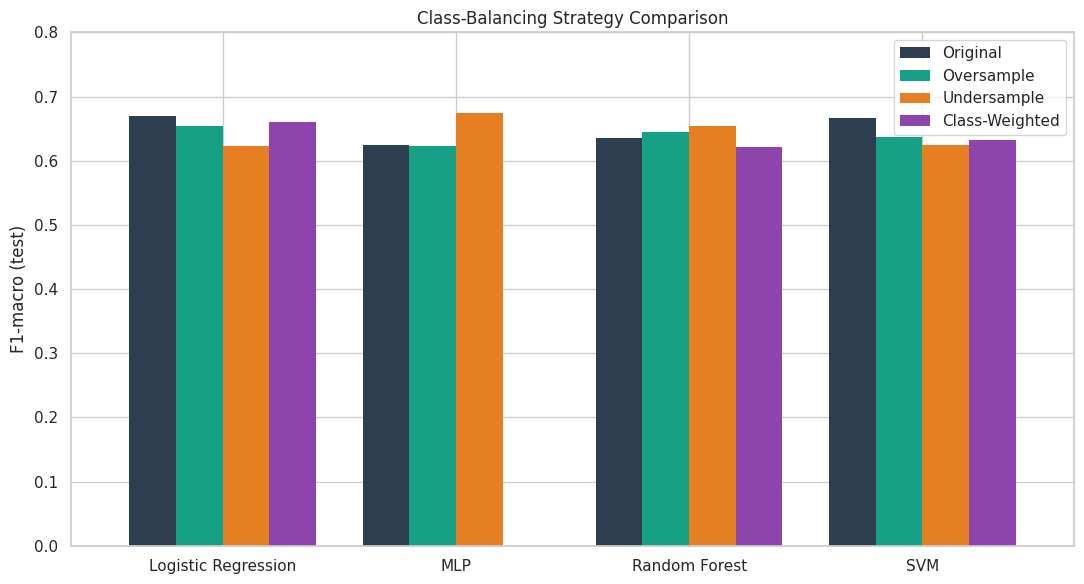

In [11]:
# Figure 3 — Class-balancing strategy comparison (macro-F1)
order = ['Original', 'Oversample', 'Undersample', 'Class-Weighted']
balp = bal[order]
colors = ['#2c3e50', '#16a085', '#e67e22', '#8e44ad']
ax = balp.plot(kind='bar', figsize=(11, 6), color=colors, width=0.8, edgecolor='none')
ax.set_ylabel('F1-macro (test)'); ax.set_ylim(0, 0.8); ax.set_xlabel('')
ax.set_title('Class-Balancing Strategy Comparison')
plt.xticks(rotation=0); plt.legend(title=None)
plt.tight_layout(); plt.savefig('figures/fig4_balancing.png', dpi=130, bbox_inches='tight'); plt.show()

## 7. Hyperparameter tuning (GridSearchCV)
**GridSearchCV** exhaustively tries every combination in a parameter grid, evaluating each with
cross-validation (here 3-fold) on the *training* data, and keeps the combination with the best mean score.
This avoids tuning on the test set. We optimise for `f1_macro`.

In [12]:
grids={
 'Logistic Regression':(LogisticRegression(max_iter=1000),{'C':[0.1,1,10],'solver':['lbfgs','saga'],'penalty':['l2']}),
 'SVM':(SVC(probability=True,random_state=42),{'C':[0.1,1,10],'gamma':['scale','auto'],'kernel':['linear','rbf']}),
 'Random Forest':(RandomForestClassifier(random_state=42),
                  {'n_estimators':[50,100,200],'max_depth':[None,10,20],'min_samples_split':[2,5]}),
}
for name,(m,g) in grids.items():
    s=GridSearchCV(m,g,cv=3,scoring='f1_macro',n_jobs=-1).fit(X_train_s,y_train)
    yp=s.best_estimator_.predict(X_test_s)
    print(f"{name}: best={s.best_params_} | CV f1_macro={s.best_score_:.3f} | "
          f"test f1_macro={f1_score(y_test,yp,average='macro'):.3f}")

Logistic Regression: best={'C': 0.1, 'penalty': 'l2', 'solver': 'saga'} | CV f1_macro=0.660 | test f1_macro=0.673
SVM: best={'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'} | CV f1_macro=0.662 | test f1_macro=0.686
Random Forest: best={'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200} | CV f1_macro=0.683 | test f1_macro=0.642


## 8. Stability: 10-fold cross-validation + paired t-test
A single train/test split can be lucky. **10-fold CV** splits the training data into 10 parts, trains on 9
and tests on 1, ten times, giving a mean and a standard deviation (lower std = more stable). We then use a
**paired t-test** to check whether the difference between the two strongest models is statistically
significant (p < 0.05) rather than random.

In [13]:
skf=StratifiedKFold(n_splits=10,shuffle=True,random_state=42)
cvrows=[]
for name,m in models.items():
    r=cross_validate(m,X_train_s,y_train,cv=skf,scoring=['accuracy','f1_macro'],n_jobs=-1)
    cvrows.append({'Model':name,'Mean Acc':round(r['test_accuracy'].mean(),3),
                   'Std Acc':round(r['test_accuracy'].std(),3),
                   'Mean F1':round(r['test_f1_macro'].mean(),3),
                   'Std F1':round(r['test_f1_macro'].std(),3)})
print(pd.DataFrame(cvrows).to_string(index=False))

rf=cross_val_score(RandomForestClassifier(n_estimators=100,random_state=42),X_train_s,y_train,cv=skf,scoring='f1_macro')
mlp=cross_val_score(MLPClassifier(hidden_layer_sizes=(64,32),max_iter=500,random_state=42),X_train_s,y_train,cv=skf,scoring='f1_macro')
t,p=stats.ttest_rel(rf,mlp)
print(f"\nPaired t-test RF vs MLP: RF={rf.mean():.3f}, MLP={mlp.mean():.3f}, t={t:.3f}, p={p:.4f}")
print('Difference is', 'significant' if p<0.05 else 'NOT statistically significant', '(alpha=0.05)')

              Model  Mean Acc  Std Acc  Mean F1  Std F1
Logistic Regression     0.622    0.054    0.659   0.080
                SVM     0.612    0.064    0.652   0.074
      Random Forest     0.622    0.026    0.670   0.034
                MLP     0.595    0.043    0.645   0.057

Paired t-test RF vs MLP: RF=0.670, MLP=0.645, t=1.557, p=0.1539
Difference is NOT statistically significant (alpha=0.05)


### Figure 4 — Cross-validation stability plot
Mean 10-fold macro-F1 with standard-deviation error bars per model (reproduces Figure 4 in the report).

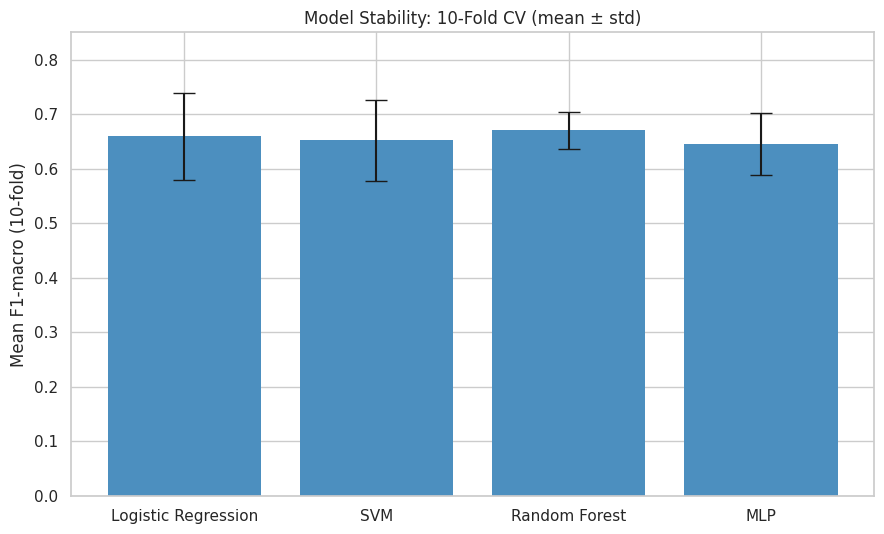

In [14]:
# Figure 4 — Model stability across 10 folds (mean +/- std macro-F1)
cvdf = pd.DataFrame(cvrows).set_index('Model')
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(cvdf.index, cvdf['Mean F1'], yerr=cvdf['Std F1'], capsize=8, color='#4C8FBF', edgecolor='none')
ax.set_ylabel('Mean F1-macro (10-fold)'); ax.set_ylim(0, 0.85)
ax.set_title('Model Stability: 10-Fold CV (mean ± std)')
plt.tight_layout(); plt.savefig('figures/fig5_cv_stability.png', dpi=130, bbox_inches='tight'); plt.show()

## 9. Feature importance after the fix
With the leaking `Psychological Wellness` dummies removed, Gini importance now highlights *genuine*
lifestyle predictors (coping by exercise, interest in quitting, alcohol intake, field of study) instead of
copies of the label. This is exactly the check the markers asked for.

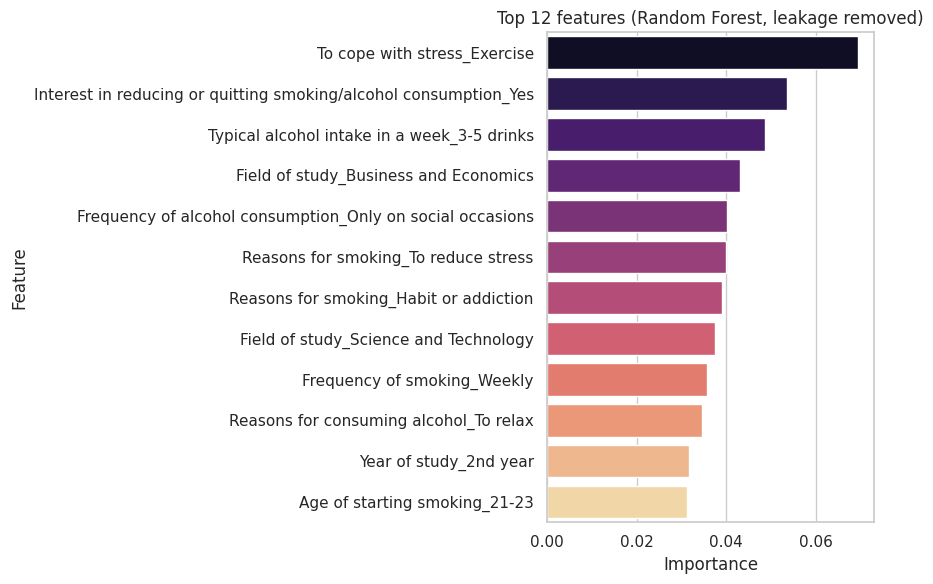

                                                         Feature  Importance
                                    To cope with stress_Exercise    0.069534
Interest in reducing or quitting smoking/alcohol consumption_Yes    0.053593
                     Typical alcohol intake in a week_3-5 drinks    0.048662
                           Field of study_Business and Economics    0.043037
       Frequency of alcohol consumption_Only on social occasions    0.040161
                            Reasons for smoking_To reduce stress    0.039862
                          Reasons for smoking_Habit or addiction    0.038961
                           Field of study_Science and Technology    0.037584
                                     Frequency of smoking_Weekly    0.035786
                          Reasons for consuming alcohol_To relax    0.034566


In [15]:
rf=RandomForestClassifier(n_estimators=100,random_state=42).fit(X_train_s,y_train)
imp=pd.DataFrame({'Feature':X.columns,'Importance':rf.feature_importances_}).sort_values('Importance',ascending=False)
plt.figure(figsize=(9,6))
sns.barplot(data=imp.head(12),x='Importance',y='Feature',palette='magma')
plt.title('Top 12 features (Random Forest, leakage removed)'); plt.tight_layout(); plt.show()
print(imp.head(10).to_string(index=False))